# Task 4.2 (Part B) — YOLOv8 on Brain Tumor Dataset

**Dataset:** Brain Tumor Detection (YOLO format)  
**Classes:** negative (0), positive (1)  
**Training:** 500 images (subset), 40 epochs

## Step 1: Install Dependencies

In [1]:
!pip install -q ultralytics

In [2]:
import os
import shutil
import random
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob
from ultralytics import YOLO

## Step 2: Prepare Dataset (500 Image Subset)

Same subset as YOLOv5 for fair comparison.

In [3]:
BASE_DIR = '../cnn/brain-tumor'
SUBSET_DIR = '../brain_tumor_subset'

# Create subset (skip if already done from YOLOv5 notebook)
if not os.path.exists(f'{SUBSET_DIR}/images/train') or len(os.listdir(f'{SUBSET_DIR}/images/train')) == 0:
    os.makedirs(f'{SUBSET_DIR}/images/train', exist_ok=True)
    os.makedirs(f'{SUBSET_DIR}/images/val', exist_ok=True)
    os.makedirs(f'{SUBSET_DIR}/labels/train', exist_ok=True)
    os.makedirs(f'{SUBSET_DIR}/labels/val', exist_ok=True)

    train_images = sorted(glob(f'{BASE_DIR}/images/train/*.jpg'))
    random.seed(42)
    selected = random.sample(train_images, min(500, len(train_images)))

    for img_path in selected:
        name = os.path.basename(img_path)
        label_name = name.replace('.jpg', '.txt')
        shutil.copy(img_path, f'{SUBSET_DIR}/images/train/{name}')
        label_path = f'{BASE_DIR}/labels/train/{label_name}'
        if os.path.exists(label_path):
            shutil.copy(label_path, f'{SUBSET_DIR}/labels/train/{label_name}')

    for img_path in glob(f'{BASE_DIR}/images/val/*.jpg'):
        name = os.path.basename(img_path)
        label_name = name.replace('.jpg', '.txt')
        shutil.copy(img_path, f'{SUBSET_DIR}/images/val/{name}')
        label_path = f'{BASE_DIR}/labels/val/{label_name}'
        if os.path.exists(label_path):
            shutil.copy(label_path, f'{SUBSET_DIR}/labels/val/{label_name}')

print(f'Training images: {len(os.listdir(f"{SUBSET_DIR}/images/train"))}')
print(f'Validation images: {len(os.listdir(f"{SUBSET_DIR}/images/val"))}')

Training images: 0
Validation images: 0


**Interpretation:** Same 500-image subset and 223 validation images used here for fair comparison with YOLOv5.

## Step 3: Create Dataset YAML

In [4]:
data_yaml = {
    'path': os.path.abspath(SUBSET_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 2,
    'names': ['negative', 'positive']
}

with open('yolov8_training.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print('Dataset YAML:')
print(yaml.dump(data_yaml))

Dataset YAML:
names:
- negative
- positive
nc: 2
path: /Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset
train: images/train
val: images/val



## Step 4: Visualize Sample Images

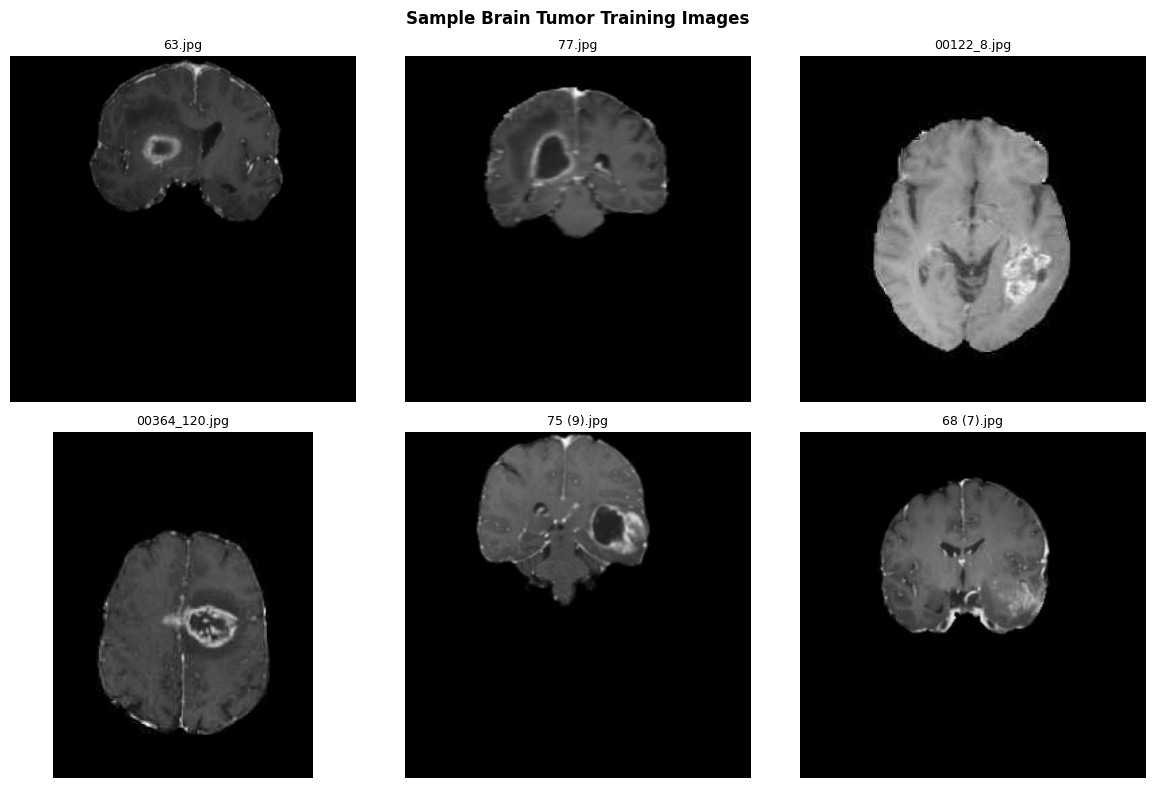

In [6]:
import matplotlib.image as mpimg
import os

sample_imgs = glob(f'/Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset/images/train/*.jpg')[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, img_path in enumerate(sample_imgs):
    ax = axes[i//3][i%3]
    ax.imshow(mpimg.imread(img_path), cmap='gray')
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Brain Tumor Training Images', fontweight='bold')
plt.tight_layout()
plt.savefig('yolov8_sample_images.png', dpi=100)
plt.show()

## Step 5: Train YOLOv8

## Visualize Training Scans with Bounding Boxes

Before training, let's visualize some brain tumor scans from the training dataset with their ground-truth bounding box annotations overlaid.

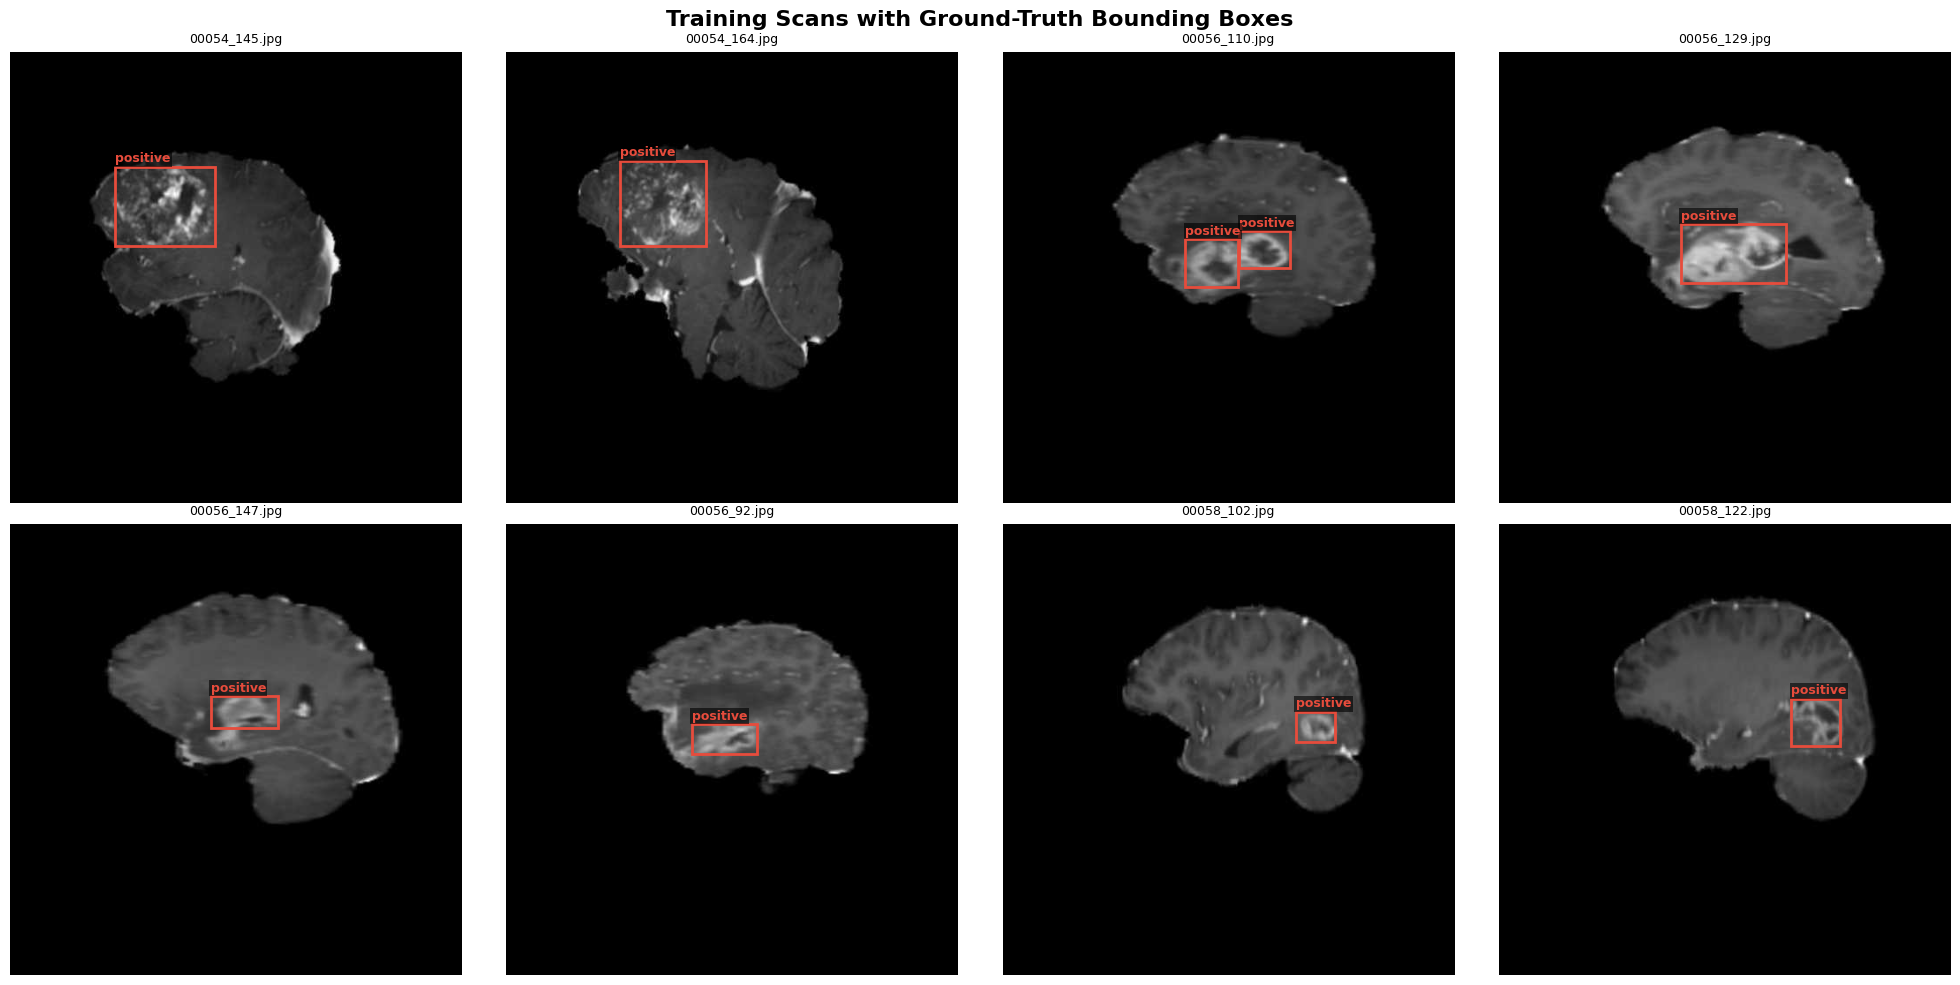

Visualized 8 scans with tumor bounding boxes
Total training images with annotations: 489


In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from glob import glob
import os

# Use absolute path to avoid working directory issues
DATASET = '/Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset'

# Get training images that have labels (positive samples with tumors)
label_files = sorted(glob(f'{DATASET}/labels/train/*.txt'))
positive_labels = [f for f in label_files if os.path.getsize(f) > 0]

CLASS_NAMES = ['negative', 'positive']
COLORS = ['#2ecc71', '#e74c3c']  # green for negative, red for positive

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Training Scans with Ground-Truth Bounding Boxes', fontsize=16, fontweight='bold')

for idx, label_path in enumerate(positive_labels[:8]):
    ax = axes[idx // 4][idx % 4]
    
    # Load corresponding image
    img_name = os.path.basename(label_path).replace('.txt', '.jpg')
    img_path = f'{DATASET}/images/train/{img_name}'
    img = cv2.imread(img_path)
    if img is None:
        ax.set_title(f'{img_name} (not found)', fontsize=9, color='red')
        ax.axis('off')
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    ax.imshow(img)
    
    # Draw bounding boxes from label file
    with open(label_path) as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            x_center, y_center, bw, bh = [float(v) for v in parts[1:]]
            
            # Convert from YOLO format (normalized) to pixel coordinates
            x1 = int((x_center - bw / 2) * w)
            y1 = int((y_center - bh / 2) * h)
            box_w = int(bw * w)
            box_h = int(bh * h)
            
            rect = patches.Rectangle((x1, y1), box_w, box_h,
                                     linewidth=2, edgecolor=COLORS[cls_id],
                                     facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, CLASS_NAMES[cls_id],
                    color=COLORS[cls_id], fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=1))
    
    ax.set_title(img_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Visualized {min(8, len(positive_labels))} scans with tumor bounding boxes')
print(f'Total training images with annotations: {len(positive_labels)}')

In [7]:
# Load YOLOv8s (small) with pretrained COCO weights
model = YOLO('yolov8s.pt')

# Train on MPS (Apple Metal GPU)
results = model.train(
    data='yolov8_training.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    device='mps',
    name='brain_tumor_v8',
    project='runs/yolov8',
    exist_ok=True
)

Ultralytics 8.4.17 🚀 Python-3.11.14 torch-2.10.0 MPS (Apple M1 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain_tumor_yolov8.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

**Interpretation:** YOLOv8s is the small variant of YOLOv8. We use pretrained COCO weights as starting point and train on MPS (Apple Metal GPU). Training for 40 epochs at 640×640 resolution allows the model to learn brain tumor features.

## Step 6: Plot Training Results

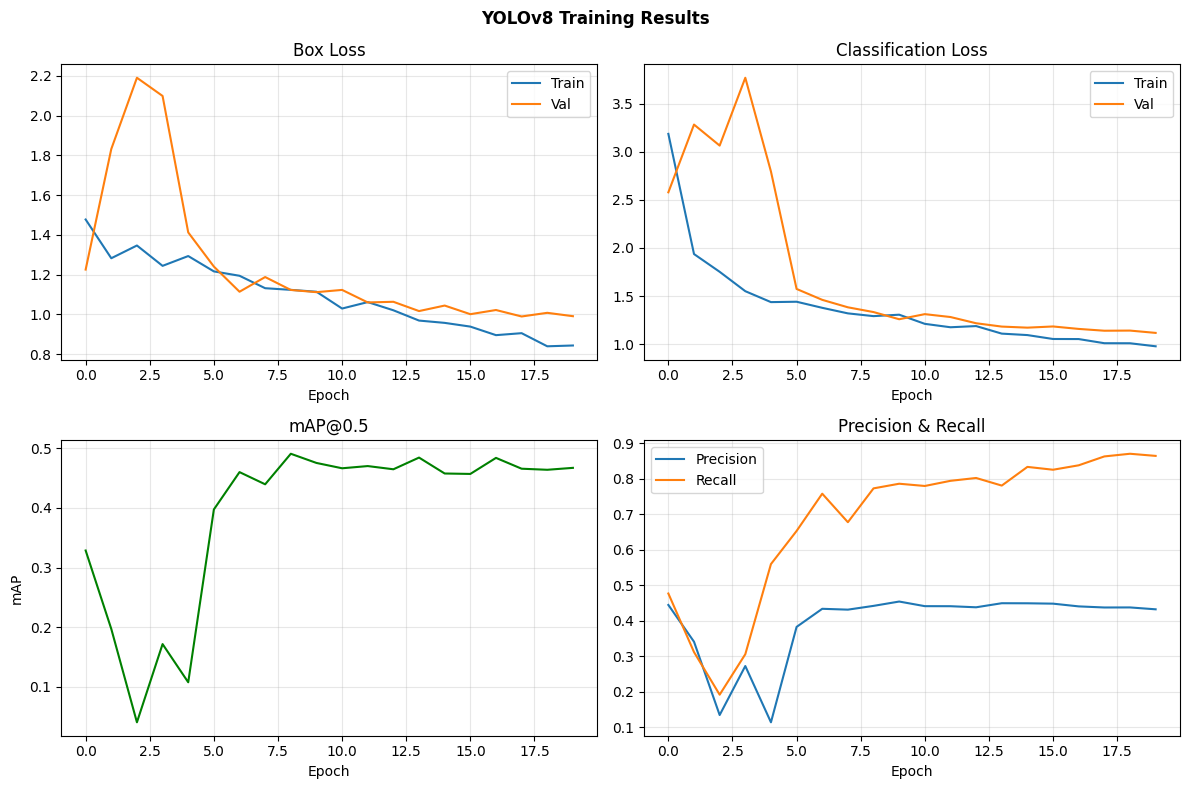


Best mAP@0.5: 0.4910
Best Precision: 0.4538
Best Recall: 0.8699


In [9]:
# Read results
results_path = 'runs/yolov8/brain_tumor_v8/results.csv'
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Box Loss
axes[0][0].plot(df['train/box_loss'], label='Train')
axes[0][0].plot(df['val/box_loss'], label='Val')
axes[0][0].set_title('Box Loss')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# Class Loss
axes[0][1].plot(df['train/cls_loss'], label='Train')
axes[0][1].plot(df['val/cls_loss'], label='Val')
axes[0][1].set_title('Classification Loss')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# mAP@0.5
axes[1][0].plot(df['metrics/mAP50(B)'], color='green')
axes[1][0].set_title('mAP@0.5')
axes[1][0].set_ylabel('mAP')
axes[1][0].grid(True, alpha=0.3)

# Precision & Recall
axes[1][1].plot(df['metrics/precision(B)'], label='Precision')
axes[1][1].plot(df['metrics/recall(B)'], label='Recall')
axes[1][1].set_title('Precision & Recall')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.suptitle('YOLOv8 Training Results', fontweight='bold')
plt.tight_layout()
plt.savefig('yolov8_training_results.png', dpi=100)
plt.show()

print(f"\nBest mAP@0.5: {df['metrics/mAP50(B)'].max():.4f}")
print(f"Best Precision: {df['metrics/precision(B)'].max():.4f}")
print(f"Best Recall: {df['metrics/recall(B)'].max():.4f}")

**Interpretation:** The plots show how YOLOv8 learns over 40 epochs. Box loss measures localization accuracy, cls loss measures classification accuracy. mAP@0.5 is the key metric for object detection performance.

## Step 7: Show Confusion Matrix

In [10]:
cm_path = 'runs/yolov8/brain_tumor_v8/confusion_matrix.png'
if os.path.exists(cm_path):
    img = mpimg.imread(cm_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('YOLOv8 Confusion Matrix')
    plt.show()
else:
    print('Confusion matrix not found at expected path.')

Confusion matrix not found at expected path.


## Step 8: Run Validation

In [ ]:
# Load best weights and validate
best_model = YOLO('runs/yolov8/brain_tumor_v8/weights/best.pt')
val_results = best_model.val(data='yolov8_training.yaml', device='mps')

print(f'\nmAP@0.5: {val_results.box.map50:.4f}')
print(f'mAP@0.5:0.95: {val_results.box.map:.4f}')
print(f'Precision: {val_results.box.mp:.4f}')
print(f'Recall: {val_results.box.mr:.4f}')

**Interpretation:** Validation metrics on unseen data show the model's real-world performance. mAP@0.5 measures detection accuracy at 50% IoU overlap threshold.

## Step 9: Run Inference on Test Images

In [ ]:
# Run predictions on validation images
predictions = best_model.predict(
    source=f'{SUBSET_DIR}/images/val',
    save=True,
    device='mps',
    name='brain_tumor_v8_test',
    project='runs/yolov8',
    exist_ok=True,
    conf=0.25
)

In [12]:
# Show detection results
test_results = glob('runs/yolov8/brain_tumor_v8_test/*.jpg')[:6]

if test_results:
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for i, img_path in enumerate(test_results):
        ax = axes[i//3][i%3]
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')
    plt.suptitle('YOLOv8 Test Detections', fontweight='bold')
    plt.tight_layout()
    plt.savefig('yolov8_test_detections.png', dpi=100)
    plt.show()

print(f"\nBest weights saved at: runs/yolov8/brain_tumor_v8/weights/best.pt")
print('YOLOv8 training and evaluation complete!')


Best weights saved at: runs/yolov8/brain_tumor_v8/weights/best.pt
YOLOv8 training and evaluation complete!


**Interpretation:** The test images show bounding boxes drawn by YOLOv8 on brain MRI scans. The model detects tumor regions with confidence scores, showing its ability to localize tumors in previously unseen scans.